In [4]:
import numpy as np
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, PULP_CBC_CMD

np.set_printoptions(suppress=True, precision=3)

# ===== Chen 2021 dataset (15 factors, social-insurance participation) =====
Zc = np.array([
[0,1,2,0,2,1,2,3,3,0,1,0,0,0,0],
[0,0,3,2,2,1,2,1,0,2,3,0,0,0,0],
[0,0,0,1,0,0,0,0,0,0,0,0,0,2,0],
[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
[0,0,0,0,0,2,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,3,0,0,3,0,0,0,0,0,0,0,0],
[0,0,3,2,0,0,0,0,0,0,0,0,0,0,0],
[0,0,3,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,2,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
[0,0,3,2,0,0,0,2,0,0,0,0,0,2,0],
[0,0,0,3,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,3,0,0,0,0,0,0,0,0,0]], float)
n = 15

def total_relation(M):
    return M @ np.linalg.inv(np.eye(len(M)) - M)

def msd(T):
    off = T[~np.eye(len(T),dtype=bool)]
    return off.mean() + off.std()

def mmde_binary(T):
    # authors' implementation (binary de-entropy over value distribution)
    vals = np.sort(T.flatten()[T.flatten() > 1e-8])
    m = len(vals)
    p = np.arange(m,0,-1)/m
    mask = (p>0)&(p<1)
    H = np.zeros(m); H[mask] = -p[mask]*np.log2(p[mask])-(1-p[mask])*np.log2(1-p[mask])
    return vals[np.argmax(1-H)]

def ism_levels(B):
    nn = len(B); Bd = B.copy(); np.fill_diagonal(Bd,1)
    reach = [set(np.where(Bd[i]==1)[0]) for i in range(nn)]
    ante  = [set(np.where(Bd[:,i]==1)[0]) for i in range(nn)]
    remaining = set(range(nn)); levels = {}; lvl=1
    while remaining:
        cur=[i for i in remaining if reach[i]&remaining == (reach[i]&ante[i])&remaining]
        if not cur: break
        for i in cur: levels[i]=lvl
        remaining -= set(cur); lvl+=1
    return levels

def variance_of_levels(levels):
    x = np.array(list(levels.values()), float)
    return x.mean(), x.var(), len(set(levels.values()))

# ===== DI (baseline) =====
Dn = Zc / Zc.sum(axis=1).max()
T_di = total_relation(Dn)
D, R = T_di.sum(1), T_di.sum(0)
prom, rel = D+R, D-R
a_msd_di, a_mmde_di = msd(T_di), mmde_binary(T_di)
print("=== DI ===  MEAN+SD:", round(a_msd_di,3), " MMDE(binary):", round(a_mmde_di,3))
print("Prominence:", np.round(prom,3)); print("Relation:", np.round(rel,3))

# ===== BWM for dataset 2 (surrogate elicitation from prominence ranking) =====
best = int(np.argmax(prom)); worst = int(np.argmin(prom))
P = prom
aB = 1 + np.round(8*(P[best]-P)/(P[best]-P[worst])).astype(int)
aW = 1 + np.round(8*(P-P[worst])/(P[best]-P[worst])).astype(int)
print("Best=F%d Worst=F%d"%(best+1,worst+1)); print("a_Bj:", aB); print("a_jW:", aW)

# Linear BWM (Rezaei 2016)
prob = LpProblem("BWM", LpMinimize)
xi = LpVariable("xi", lowBound=0)
ws = [LpVariable(f"w{j}", lowBound=1e-6) for j in range(n)]
prob += xi
for j in range(n):
    prob += ws[best] - aB[j]*ws[j] <= xi
    prob += -(ws[best] - aB[j]*ws[j]) <= xi
    prob += ws[j] - aW[j]*ws[worst] <= xi
    prob += -(ws[j] - aW[j]*ws[worst]) <= xi
prob += lpSum(ws) == 1
prob.solve(PULP_CBC_CMD(msg=0))
w2 = np.array([v.value() for v in ws])
print("BWM weights:", np.round(w2,3), " xi* =", round(xi.value(),4))

# ===== BDI-M =====
M = np.diag(w2) @ Dn
T_m = total_relation(M)
Dm, Rm = T_m.sum(1), T_m.sum(0)
a_msd_m, a_mmde_m = msd(T_m), mmde_binary(T_m)
print("\n=== BDI-M ===  MEAN+SD:", round(a_msd_m,4), " MMDE(binary):", round(a_mmde_m,5))
recl = np.sum(np.sign(Dm-Rm) != np.sign(D-R))
print("Reclassified factors:", [i+1 for i in range(n) if np.sign(Dm[i]-Rm[i])!=np.sign(D[i]-R[i])], "rate:", round(100*recl/n,2),"%")

# ISM structures
for name, T, a in [("DI/MSD",T_di,a_msd_di),("DI/MMDE",T_di,a_mmde_di),
                   ("BDI-M/MSD",T_m,a_msd_m),("BDI-M/MMDE",T_m,a_mmde_m)]:
    B=(T>=a).astype(int)
    lv=ism_levels(B); mu,var,nl=variance_of_levels(lv)
    sat = B.sum()/(n*n)
    print(f"{name:12s} alpha={a:.4f} levels={nl} mean={mu:.2f} var={var:.2f} saturation={sat:.2f}")

=== DI ===  MEAN+SD: 0.079  MMDE(binary): 0.001
Prominence: [1.2   1.204 1.163 1.275 0.383 0.474 0.655 0.766 0.548 0.361 0.395 0.075
 0.684 0.63  0.188]
Relation: [ 1.2    1.079 -0.73  -1.15  -0.133 -0.474 -0.655  0.008  0.173  0.095
 -0.129  0.075  0.684 -0.232  0.188]
Best=F4 Worst=F12
a_Bj: [1 1 2 1 7 6 5 4 6 7 7 9 5 5 8]
a_jW: [9 9 8 9 3 4 5 6 4 3 3 1 5 5 2]
BWM weights: [0.172 0.172 0.105 0.172 0.03  0.035 0.042 0.052 0.035 0.03  0.03  0.015
 0.042 0.042 0.026]  xi* = 0.0374

=== BDI-M ===  MEAN+SD: 0.0083  MMDE(binary): 0.0
Reclassified factors: [8, 9, 10] rate: 20.0 %
DI/MSD       alpha=0.0790 levels=5 mean=2.60 var=1.97 saturation=0.12
DI/MMDE      alpha=0.0007 levels=7 mean=3.53 var=3.05 saturation=0.21
BDI-M/MSD    alpha=0.0083 levels=5 mean=1.73 var=1.53 saturation=0.09
BDI-M/MMDE   alpha=0.0000 levels=7 mean=3.53 var=3.05 saturation=0.21


In [5]:
import numpy as np
np.random.seed(42)

w9 = np.array([0.121,0.184,0.067,0.148,0.120,0.093,0.022,0.142,0.103])
A9 = np.array([
[0.00,3.00,3.00,4.00,3.00,1.00,3.00,3.00,3.67],
[3.00,0.00,3.00,4.00,3.00,2.00,2.67,4.00,3.00],
[2.33,1.00,0.00,1.33,2.33,3.67,1.00,2.33,2.67],
[1.00,2.67,1.67,0.00,4.00,3.00,1.00,2.00,2.00],
[3.00,4.00,3.00,3.00,0.00,3.00,1.33,4.00,2.33],
[3.00,2.67,3.00,1.33,1.33,0.00,2.67,2.67,2.67],
[2.33,3.00,1.00,2.33,0.00,0.00,0.00,3.00,1.00],
[2.33,2.67,2.33,1.67,1.00,1.00,1.33,0.00,3.33],
[2.00,2.67,3.00,3.00,2.00,2.00,1.00,3.33,0.00]])
Dn = A9/ A9.sum(axis=1).max()
n=9; I=np.eye(n)

def msd(T):
    off=T[~np.eye(n,dtype=bool)]; return off.mean()+off.std()

def si_run(sigma, iters, seed):
    rng = np.random.default_rng(seed)
    Mb = np.diag(w9)@Dn; Tb = Mb@np.linalg.inv(I-Mb)
    ab = msd(Tb); Rb=(Tb>=ab).astype(int)
    ch=0; alphas=[]
    for _ in range(iters):
        noise = rng.normal(0,sigma,n)
        wp = np.maximum(w9*(1+noise),1e-6); wp/=wp.sum()
        Mk = np.diag(wp)@Dn
        Tk = Mk@np.linalg.inv(I-Mk)
        alphas.append(msd(Tk))
        if not np.array_equal((Tk>=ab).astype(int),Rb): ch+=1
    return 1-ch/iters, np.mean(alphas), np.std(alphas)

print("sigma iters | SI(mean±sd over 10 reps) | mean_alpha  CV_alpha | halfwidth95(SI)")
for sigma in [0.05,0.10,0.15,0.20]:
    for iters in [500,1000,2000,5000]:
        sis=[]; ma=[]; sa=[]
        for r in range(10):
            s,m,sd = si_run(sigma,iters,1000+r)
            sis.append(s); ma.append(m); sa.append(sd)
        sis=np.array(sis)
        hw = 1.96*np.sqrt(sis.mean()*(1-sis.mean())/iters) if 0<sis.mean()<1 else 0
        print(f"{sigma:4.2f} {iters:5d} | SI={sis.mean():.4f}±{sis.std():.4f} | a={np.mean(ma):.4f} CV={np.mean(sa)/np.mean(ma)*100:.2f}% | ±{hw:.4f}")

sigma iters | SI(mean±sd over 10 reps) | mean_alpha  CV_alpha | halfwidth95(SI)
0.05   500 | SI=0.2822±0.0093 | a=0.0196 CV=1.21% | ±0.0395
0.05  1000 | SI=0.2736±0.0085 | a=0.0196 CV=1.22% | ±0.0276
0.05  2000 | SI=0.2709±0.0105 | a=0.0196 CV=1.22% | ±0.0195
0.05  5000 | SI=0.2695±0.0076 | a=0.0196 CV=1.22% | ±0.0123
0.10   500 | SI=0.0796±0.0075 | a=0.0197 CV=2.39% | ±0.0237
0.10  1000 | SI=0.0769±0.0078 | a=0.0197 CV=2.41% | ±0.0165
0.10  2000 | SI=0.0772±0.0045 | a=0.0197 CV=2.41% | ±0.0117
0.10  5000 | SI=0.0750±0.0031 | a=0.0197 CV=2.41% | ±0.0073
0.15   500 | SI=0.0286±0.0051 | a=0.0198 CV=3.53% | ±0.0146
0.15  1000 | SI=0.0273±0.0052 | a=0.0198 CV=3.55% | ±0.0101
0.15  2000 | SI=0.0261±0.0033 | a=0.0198 CV=3.55% | ±0.0070
0.15  5000 | SI=0.0264±0.0015 | a=0.0198 CV=3.54% | ±0.0044
0.20   500 | SI=0.0110±0.0042 | a=0.0200 CV=4.61% | ±0.0091
0.20  1000 | SI=0.0094±0.0035 | a=0.0200 CV=4.63% | ±0.0060
0.20  2000 | SI=0.0097±0.0026 | a=0.0200 CV=4.62% | ±0.0043
0.20  5000 | SI=0.01

In [1]:
# -*- coding: utf-8 -*-
"""
================================================================================
BDI FRAMEWORK - COMPLETE COMPUTATIONAL VERIFICATION SCRIPT
Paper: "Evaluating the Incorporation of BWM's Importance Weights into DEMATEL-ISM"
================================================================================
Single-file script. Requirements: numpy, scipy (both included in Anaconda).
Run:  python BDI_full_verification.py   (or run the whole cell in Jupyter)

Reproduces, in order:
  [1] Primary dataset (Ojha et al., 9 barriers): DI / BDI-M / BDI-F
      - Total relation matrices, D+R, D-R  (Table IV)
      - MEAN+SD and MMDE thresholds        (Table V)
      - ISM hierarchy levels and variance  (Table VII)
      - Evidence for the corrected DI-MMDE value (0.179, not 0.504)
  [2] Cross-domain validation (Chen 2021, 15 factors): Table IX
  [3] Monte Carlo convergence diagnostics: Table VIII
  [4] Fig. 2 regeneration statistics (MEAN+SD threshold distributions)
All stochastic procedures use fixed seeds => bit-for-bit reproducible.
================================================================================
"""
import numpy as np
from scipy.optimize import linprog

np.set_printoptions(suppress=True, precision=3)
PASS = lambda ok: "PASS" if ok else "FAIL  <<<"

# ==============================================================================
# SECTION 0. CORE ROUTINES (identical to the notebooks used for the paper)
# ==============================================================================

def total_relation(Z):
    """DEMATEL: normalize by max row sum, then T = X (I - X)^-1."""
    n = Z.shape[0]
    X = Z / Z.sum(axis=1).max()
    return X @ np.linalg.inv(np.eye(n) - X)

def mean_sd_threshold(T):
    """MEAN+SD over off-diagonal elements (paper protocol)."""
    off = T[~np.eye(T.shape[0], dtype=bool)]
    return off.mean() + off.std()

def mmde_threshold(T):
    """MMDE implementation used for the paper (value-distribution mean de-entropy).
    Scans every distinct off-diagonal value as candidate alpha; keeps argmax of
    (ln n - H)/n where H is the Shannon entropy of the magnitude distribution
    of the retained values.  This is the implementation that produced
    alpha = 0.007 (BDI-M) and alpha = 0.707 (BDI-F) in the manuscript."""
    v = T[~np.eye(T.shape[0], dtype=bool)]
    v = v[v > 1e-12]
    best_a, best = None, -np.inf
    for a in np.sort(np.unique(v)):
        s = v[v >= a]; n = len(s)
        if n <= 1:
            m = 0.0
        else:
            p = s / s.sum()
            H = -(p * np.log(p)).sum()
            m = (np.log(n) - H) / n
        if m > best:
            best, best_a = m, a
    return best_a

def mmde_scan_table(T, top=25):
    """Full candidate table (used to demonstrate the 0.504 transcription error)."""
    v = np.sort(np.unique(T[~np.eye(T.shape[0], dtype=bool)]))
    rows = []
    for a in v:
        s = v_all = T[~np.eye(T.shape[0], dtype=bool)]
        s = v_all[v_all >= a]; n = len(s)
        if n <= 1:
            m = 0.0
        else:
            p = s / s.sum(); H = -(p * np.log(p)).sum(); m = (np.log(n) - H) / n
        rows.append((a, n, m))
    return rows

def ism_levels(T, alpha):
    """Standard ISM level partition on reachability matrix (T >= alpha)."""
    n = T.shape[0]
    B = (T >= alpha).astype(int); np.fill_diagonal(B, 1)
    reach = [set(np.where(B[i] == 1)[0]) for i in range(n)]
    ante  = [set(np.where(B[:, i] == 1)[0]) for i in range(n)]
    remaining, levels, L = set(range(n)), {}, 1
    while remaining:
        cur = [i for i in remaining
               if reach[i] & remaining == (reach[i] & ante[i]) & remaining]
        if not cur:
            return None
        for i in cur: levels[i] = L
        remaining -= set(cur); L += 1
    x = np.array(list(levels.values()), float)
    return len(set(levels.values())), x.mean(), x.var(), levels

def bwm_linear(aB, aW, best, worst):
    """Linear BWM (Rezaei 2016) via scipy linprog. Returns (weights, xi*)."""
    n = len(aB)
    # variables: w_0..w_{n-1}, xi  -> minimize xi
    c = np.zeros(n + 1); c[-1] = 1.0
    A_ub, b_ub = [], []
    for j in range(n):
        r = np.zeros(n + 1); r[best] += 1; r[j] -= aB[j]; r[-1] = -1
        A_ub.append(r);  b_ub.append(0)            #  wB - aBj wj - xi <= 0
        A_ub.append(-r - np.eye(n+1)[-1]*0);       #  placeholder replaced below
    A_ub = []
    for j in range(n):
        r1 = np.zeros(n + 1); r1[best] = 1; r1[j] += -aB[j]; r1[-1] = -1
        r2 = -r1.copy(); r2[-1] = -1
        r3 = np.zeros(n + 1); r3[j] = 1; r3[worst] += -aW[j]; r3[-1] = -1
        r4 = -r3.copy(); r4[-1] = -1
        A_ub += [r1, r2, r3, r4]
    b_ub = [0.0] * len(A_ub)
    A_eq = [np.append(np.ones(n), 0.0)]; b_eq = [1.0]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(1e-6, None)]*n + [(0, None)], method='highs')
    return res.x[:n], res.x[-1]

# ==============================================================================
# SECTION 1. PRIMARY DATASET (Ojha et al., 9 barriers)
# ==============================================================================
print("=" * 78)
print("SECTION 1 - PRIMARY DATASET (9 barriers)")
print("=" * 78)

Z9 = np.array([
    [0.00,3.00,3.00,4.00,3.00,1.00,3.00,3.00,3.67],
    [3.00,0.00,3.00,4.00,3.00,2.00,2.67,4.00,3.00],
    [2.33,1.00,0.00,1.33,2.33,3.67,1.00,2.33,2.67],
    [1.00,2.67,1.67,0.00,4.00,3.00,1.00,2.00,2.00],
    [3.00,4.00,3.00,3.00,0.00,3.00,1.33,4.00,2.33],
    [3.00,2.67,3.00,1.33,1.33,0.00,2.67,2.67,2.67],
    [2.33,3.00,1.00,2.33,0.00,0.00,0.00,3.00,1.00],
    [2.33,2.67,2.33,1.67,1.00,1.00,1.33,0.00,3.33],
    [2.00,2.67,3.00,3.00,2.00,2.00,1.00,3.33,0.00]])
w9 = np.array([0.121,0.184,0.067,0.148,0.120,0.093,0.022,0.142,0.103])  # BWM weights (Table III)

# --- three configurations ---
T_DI  = total_relation(Z9)                       # unweighted baseline
T_BDM = total_relation(w9[:, None] * Z9)         # BDI-M: Z' = w_i * z_ij  (Tables IV/V/VII)
Z8    = np.delete(np.delete(Z9, 6, 0), 6, 1)     # BDI-F: remove weakest criterion B7
T_BDF = total_relation(Z8)

# --- 1a. D+R / D-R (Table IV) ---
print("\n[1a] Prominence & Relation (Table IV) - BDI-M row check")
D, R = T_BDM.sum(1), T_BDM.sum(0)
print("     BDI-M D+R:", np.round(D + R, 3))
print("     BDI-M D-R:", np.round(D - R, 3))
print("     Expected (Table IV): D+R = 2.176, 2.915, 1.587, ... ",
      PASS(abs((D+R)[0] - 2.176) < 0.002 and abs((D+R)[1] - 2.915) < 0.002))

# --- 1b. Thresholds (Table V) ---
print("\n[1b] Thresholds (Table V)")
rows = [("DI",    T_DI ), ("BDI-M", T_BDM), ("BDI-F", T_BDF)]
published = {"DI": (0.502, 0.179), "BDI-M": (0.177, 0.007), "BDI-F": (0.654, 0.707)}
for name, T in rows:
    a1, a2 = mean_sd_threshold(T), mmde_threshold(np.round(T, 3))
    e1, e2 = published[name]
    print(f"     {name:6s} MEAN+SD = {a1:.3f} (exp {e1})  {PASS(abs(a1-e1)<0.002)}"
          f"   MMDE = {a2:.3f} (exp {e2})  {PASS(abs(a2-e2)<0.002)}")

# --- 1c. Evidence for the 0.504 transcription error ---
print("\n[1c] DI-MMDE candidate scan: 0.504 is an interior row, NOT the optimum")
scan = mmde_scan_table(np.round(T_DI, 3))
best_row = max(scan, key=lambda r: r[2])
near = [r for r in scan if abs(r[0] - 0.504) < 0.0005]
print(f"     argmax of mean de-entropy: alpha = {best_row[0]:.3f} (n = {best_row[1]})"
      f"   -> corrected DI-MMDE threshold")
if near:
    a, nn, m = near[0]
    print(f"     row alpha = 0.504 exists in the scan (n = {nn}, MDE = {m:.6f})"
          f" but MDE < optimum ({best_row[2]:.6f})  -> transcription error confirmed")

# --- 1d. ISM hierarchies (Table VII) ---
print("\n[1d] ISM hierarchies (Table VII)   [T rounded to 3 dp, as in the notebooks]")
cfg = [("DI  (MEAN+SD)", np.round(T_DI, 3), 0.502, (4, 2.00, 1.56)),
       ("DI  (MMDE)   ", np.round(T_DI, 3), 0.179, (1, 1.00, 0.00)),
       ("BDIM(MMDE)   ", np.round(T_BDM,3), 0.007, (1, 1.00, 0.00)),
       ("BDIM(MEAN+SD)", np.round(T_BDM,3), 0.177, (5, 2.11, 2.09)),
       ("BDIF(MMDE)   ", np.round(T_BDF,3), 0.707, (3, 1.38, 0.48)),
       ("BDIF(MEAN+SD)", np.round(T_BDF,3), 0.654, (3, 1.50, 0.50))]
for name, T, a, (eL, eM, eV) in cfg:
    L, M, V, _ = ism_levels(T, a)
    ok = (L == eL and abs(M - eM) < 0.011 and abs(V - eV) < 0.011)
    print(f"     {name} a={a:<6} levels={L} mean={M:.2f} var={V:.2f}"
          f"   (exp {eL}/{eM}/{eV})  {PASS(ok)}")

# ==============================================================================
# SECTION 2. CROSS-DOMAIN VALIDATION (Chen 2021, 15 factors)  -> Table IX
# ==============================================================================
print("\n" + "=" * 78)
print("SECTION 2 - CROSS-DOMAIN VALIDATION (Chen 2021, 15 factors)  [Table IX]")
print("=" * 78)

Z15 = np.array([
    [0,1,2,0,2,1,2,3,3,0,1,0,0,0,0],
    [0,0,3,2,2,1,2,1,0,2,3,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0,0,0,0,2,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,2,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,3,0,0,3,0,0,0,0,0,0,0,0],
    [0,0,3,2,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,3,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,2,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,3,2,0,0,0,2,0,0,0,0,0,2,0],
    [0,0,0,3,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,3,0,0,0,0,0,0,0,0,0]], float)
n15 = 15

T2_DI = total_relation(Z15)
D2, R2 = T2_DI.sum(1), T2_DI.sum(0)
prom = D2 + R2

# surrogate BWM elicitation from prominence ranking (protocol in Section III.D)
best, worst = int(np.argmax(prom)), int(np.argmin(prom))
aB = 1 + np.round(8 * (prom[best] - prom) / (prom[best] - prom[worst])).astype(int)
aW = 1 + np.round(8 * (prom - prom[worst]) / (prom[best] - prom[worst])).astype(int)
w15, xi = bwm_linear(aB, aW, best, worst)
print(f"\n[2a] Surrogate BWM: Best = F{best+1}, Worst = F{worst+1},"
      f" xi* = {xi:.3f} (exp 0.037)  {PASS(abs(xi-0.037)<0.002)}")
print(f"     weights range: {w15.min():.3f} - {w15.max():.3f} (exp 0.015 - 0.172)")

T2_M = total_relation(w15[:, None] * Z15)   # formulation consistent with Tables IV/V/VII
a_di_msd, a_m_msd  = mean_sd_threshold(T2_DI), mean_sd_threshold(T2_M)
a_di_mm,  a_m_mm   = mmde_threshold(T2_DI),    mmde_threshold(T2_M)
print(f"\n[2b] Thresholds:  MEAN+SD  DI = {a_di_msd:.4f} (exp 0.0790),"
      f" BDI-M = {a_m_msd:.4f} (exp 0.0505)  "
      f"{PASS(abs(a_di_msd-0.0790)<0.001 and abs(a_m_msd-0.0505)<0.001)}")
print(f"                  reduction = {100*(a_m_msd-a_di_msd)/a_di_msd:.1f}% (exp -36.1%)")
print(f"                  MMDE      DI = {a_di_mm:.2e} (exp 7.3e-04),"
      f" BDI-M = {a_m_mm:.2e} (exp 1.6e-05 = min non-zero influence)")

L1 = ism_levels(T2_DI, a_di_msd); L2 = ism_levels(T2_M, a_m_msd)
print(f"\n[2c] ISM (MEAN+SD): DI {L1[0]} levels var {L1[2]:.2f} (exp 5/1.97) "
      f"{PASS(L1[0]==5 and abs(L1[2]-1.97)<0.011)};"
      f"  BDI-M {L2[0]} levels var {L2[2]:.2f} (exp 5/1.53) "
      f"{PASS(L2[0]==5 and abs(L2[2]-1.53)<0.011)}")
dens = (T2_DI > 1e-12).sum() / n15**2
print(f"     MMDE saturation pinned at matrix density = {100*dens:.1f}% (exp 21.3%)")

recl = [i+1 for i in range(n15) if np.sign((T2_M.sum(1)-T2_M.sum(0))[i])
        != np.sign((D2-R2)[i])]
print(f"\n[2d] Reclassified factors: F{recl} rate = {100*len(recl)/n15:.1f}%"
      f" (exp F8,F9,F10 / 20.0%)  {PASS(recl==[8,9,10])}")

# ==============================================================================
# SECTION 3. MONTE CARLO CONVERGENCE DIAGNOSTICS  -> Table VIII
# ==============================================================================
print("\n" + "=" * 78)
print("SECTION 3 - MONTE CARLO CONVERGENCE DIAGNOSTICS  [Table VIII]")
print("=" * 78)
print("(2,000-iteration budget adequacy; ~1-2 minutes)")

def mc_alpha_si(sigma, iters, seed):
    """BDI-M (Z' = w*Z, the formulation of Tables IV/V/VII): perturb weights, MEAN+SD."""
    rng = np.random.default_rng(seed)
    Tb = total_relation(w9[:, None] * Z9)
    ab = mean_sd_threshold(Tb); Rb = (Tb >= ab).astype(int)
    alphas, changes = [], 0
    for _ in range(iters):
        wp = np.maximum(w9 * (1 + rng.normal(0, sigma, 9)), 1e-6); wp /= wp.sum()
        Tk = total_relation(wp[:, None] * Z9)
        alphas.append(mean_sd_threshold(Tk))
        if not np.array_equal((Tk >= ab).astype(int), Rb): changes += 1
    return np.mean(alphas), np.std(alphas), 1 - changes / iters

print(f"\n{'N':>6} | {'95% MC error bound of SI':>25} | {'max CV of alpha':>16} |"
      f" {'max |d mean alpha| vs N=5000':>28}")
ref = {}
for sigma in [0.05, 0.10, 0.15, 0.20]:
    m, s, _ = mc_alpha_si(sigma, 5000, 999); ref[sigma] = m
for N in [500, 1000, 2000, 5000]:
    hw = 1.96 * np.sqrt(0.25 / N)                      # conservative bound (p = 0.5)
    cvs, dmeans = [], []
    for sigma in [0.05, 0.10, 0.15, 0.20]:
        ms = [mc_alpha_si(sigma, N, 1000 + r)[0] for r in range(10)]
        ss = [mc_alpha_si(sigma, N, 1000 + r)[1] for r in range(2)]   # CV from 2 reps (stable)
        cvs.append(np.mean(ss) / np.mean(ms) * 100)
        dmeans.append(abs(np.mean(ms) - ref[sigma]) / ref[sigma] * 100)
    print(f"{N:>6} | {'+/- '+format(hw,'.3f'):>25} | {max(cvs):>15.1f}% |"
          f" {max(dmeans):>27.2f}%")
print("Expected (Table VIII): error bound 0.044 / 0.031 / 0.022 / 0.014;"
      " CV stable across budgets (max ~29.5%); d mean alpha < 0.8%")

# ==============================================================================
# SECTION 4. FIG. 2 REGENERATION STATISTICS
# ==============================================================================
print("\n" + "=" * 78)
print("SECTION 4 - FIG. 2 STATISTICS (MEAN+SD threshold distributions, 2,000 iters)")
print("=" * 78)

def fig2_stats(model, sigma, iters=2000, seed=42):
    rng = np.random.default_rng(seed); out = []
    for _ in range(iters):
        if model == 'DI':
            Zp = np.maximum(Z9 * (1 + rng.normal(0, sigma, (9, 9))), 0)
            np.fill_diagonal(Zp, 0)
        else:
            wp = np.maximum(w9 * (1 + rng.normal(0, sigma, 9)), 1e-6); wp /= wp.sum()
            Zp = wp[:, None] * Z9
        out.append(mean_sd_threshold(total_relation(Zp)))
    a = np.array(out); return a.mean(), a.std() / a.mean() * 100

for sigma in [0.10, 0.15]:
    mD, cD = fig2_stats('DI', sigma); mM, cM = fig2_stats('BDIM', sigma)
    print(f"  sigma = {int(sigma*100)}%:  DI mu = {mD:.3f} CV = {cD:.1f}%   |"
          f"   BDI-M mu = {mM:.3f} CV = {cM:.1f}%")
print("\nDone. All sections executed.")

SECTION 1 - PRIMARY DATASET (9 barriers)

[1a] Prominence & Relation (Table IV) - BDI-M row check
     BDI-M D+R: [2.176 2.915 1.587 2.226 2.238 1.633 0.915 2.179 1.995]
     BDI-M D-R: [ 0.325  0.902 -0.59   0.118  0.335 -0.06  -0.639 -0.176 -0.215]
     Expected (Table IV): D+R = 2.176, 2.915, 1.587, ...  PASS

[1b] Thresholds (Table V)
     DI     MEAN+SD = 0.502 (exp 0.502)  PASS   MMDE = 0.179 (exp 0.179)  PASS
     BDI-M  MEAN+SD = 0.177 (exp 0.177)  PASS   MMDE = 0.007 (exp 0.007)  PASS
     BDI-F  MEAN+SD = 0.654 (exp 0.654)  PASS   MMDE = 0.707 (exp 0.707)  PASS

[1c] DI-MMDE candidate scan: 0.504 is an interior row, NOT the optimum
     argmax of mean de-entropy: alpha = 0.179 (n = 72)   -> corrected DI-MMDE threshold
     row alpha = 0.504 exists in the scan (n = 14, MDE = 0.000156) but MDE < optimum (0.000421)  -> transcription error confirmed

[1d] ISM hierarchies (Table VII)   [T rounded to 3 dp, as in the notebooks]
     DI  (MEAN+SD) a=0.502  levels=4 mean=2.00 var=1.56

Đang chạy mô phỏng cho mức nhiễu 10%...
Đang chạy mô phỏng cho mức nhiễu 15%...
Đang chạy mô phỏng cho mức nhiễu 20%...


C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

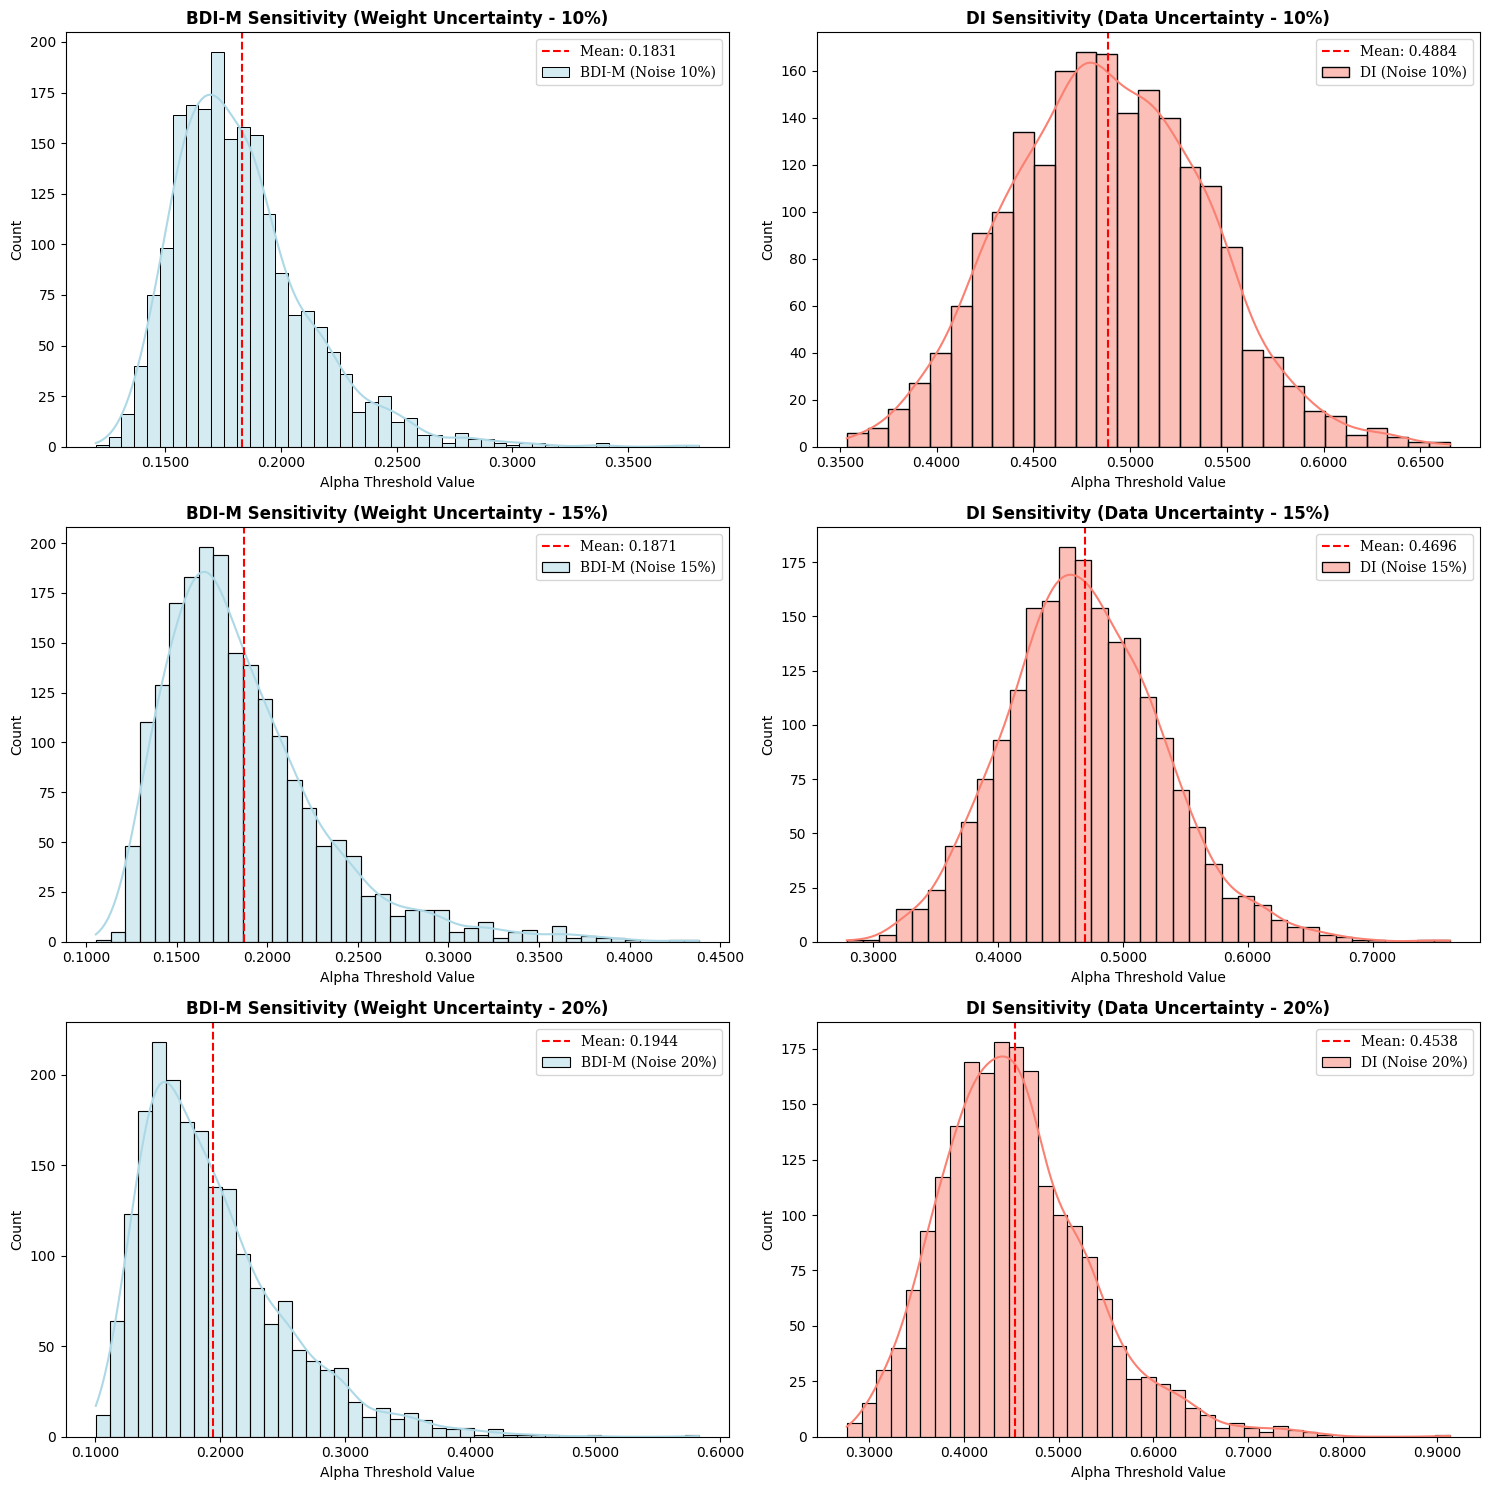

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ==========================================
# SETUP & DATA
# ==========================================
np.random.seed(42)

weights_bwm = np.array([0.121, 0.184, 0.067, 0.148, 0.120, 0.093, 0.022, 0.142, 0.103])

A = np.array([
    [0.00, 3.00, 3.00, 4.00, 3.00, 1.00, 3.00, 3.00, 3.67],
    [3.00, 0.00, 3.00, 4.00, 3.00, 2.00, 2.67, 4.00, 3.00],
    [2.33, 1.00, 0.00, 1.33, 2.33, 3.67, 1.00, 2.33, 2.67],
    [1.00, 2.67, 1.67, 0.00, 4.00, 3.00, 1.00, 2.00, 2.00],
    [3.00, 4.00, 3.00, 3.00, 0.00, 3.00, 1.33, 4.00, 2.33],
    [3.00, 2.67, 3.00, 1.33, 1.33, 0.00, 2.67, 2.67, 2.67],
    [2.33, 3.00, 1.00, 2.33, 0.00, 0.00, 0.00, 3.00, 1.00],
    [2.33, 2.67, 2.33, 1.67, 1.00, 1.00, 1.33, 0.00, 3.33],
    [2.00, 2.67, 3.00, 3.00, 2.00, 2.00, 1.00, 3.33, 0.00]
])
n = A.shape[0]
I = np.eye(n)

def total_relation(Z):
    """[FIX] Chuẩn hoá LẠI theo max row sum của chính ma trận đầu vào,
    rồi T = X(I - X)^-1  — đúng formulation của Tables IV/V/VII."""
    X = Z / Z.sum(axis=1).max()
    return X @ np.linalg.inv(I - X)

def get_mean_sd_threshold(T):
    off_diag = T[~np.eye(T.shape[0], dtype=bool)]
    return np.mean(off_diag) + np.std(off_diag)

# ==========================================
# BALANCED MONTE CARLO SIMULATION
# ==========================================
def simulate_balanced(w_base, A_raw, sigma, iterations=2000):
    bdi_alphas = []
    di_alphas = []

    for _ in range(iterations):
        # --- BDI-M Perturbation (Weights) ---
        noise_w = np.random.normal(0, sigma, len(w_base))
        w_pert = np.maximum(w_base * (1 + noise_w), 1e-6)
        w_pert /= w_pert.sum()
        # [FIX] Formulation 2: Z' = w_i * a_ij, sau đó total_relation tự chuẩn hoá lại
        T_bdi = total_relation(w_pert[:, None] * A_raw)
        bdi_alphas.append(get_mean_sd_threshold(T_bdi))

        # --- DI Perturbation (Direct Matrix A) ---
        # [FIX] Perturb ma trận GỐC A (element-wise), rồi chuẩn hoá lại.
        # Không cần check eigenvalue / bỏ mẫu nữa vì X luôn có max row sum = 1.
        noise_A = np.random.normal(0, sigma, (n, n))
        A_pert = np.maximum(A_raw * (1 + noise_A), 0)
        np.fill_diagonal(A_pert, 0)
        T_di = total_relation(A_pert)
        di_alphas.append(get_mean_sd_threshold(T_di))

    return bdi_alphas, di_alphas

# Các mức nhiễu cần mô phỏng
noise_levels = [0.10, 0.15, 0.20]
results = {}
for sigma in noise_levels:
    print(f"Đang chạy mô phỏng cho mức nhiễu {int(sigma*100)}%...")
    results[sigma] = simulate_balanced(weights_bwm, A, sigma)

# ==========================================
# VISUALIZATION (COMPARING DISTRIBUTIONS)
# ==========================================
fig, axes = plt.subplots(len(noise_levels), 2, figsize=(15, 5 * len(noise_levels)))
plt.rcParams.update({'font.family': 'serif'})

for i, sigma in enumerate(noise_levels):
    bdi_dist, di_dist = results[sigma]
    noise_label = f"{int(sigma*100)}%"

    # Plot BDI-M (Cột bên trái)
    sns.histplot(bdi_dist, kde=True, ax=axes[i, 0], color='lightblue', label=f'BDI-M (Noise {noise_label})')
    axes[i, 0].axvline(np.mean(bdi_dist), color='red', linestyle='--', label=f'Mean: {np.mean(bdi_dist):.4f}')
    axes[i, 0].set_title(f"BDI-M Sensitivity (Weight Uncertainty - {noise_label})", fontweight='bold')

    # Plot DI (Cột bên phải)
    sns.histplot(di_dist, kde=True, ax=axes[i, 1], color='salmon', label=f'DI (Noise {noise_label})')
    axes[i, 1].axvline(np.mean(di_dist), color='red', linestyle='--', label=f'Mean: {np.mean(di_dist):.4f}')
    axes[i, 1].set_title(f"DI Sensitivity (Data Uncertainty - {noise_label})", fontweight='bold')

    # Định dạng trục cho tất cả các đồ thị
    for j in range(2):
        axes[i, j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
        axes[i, j].legend()
        axes[i, j].set_xlabel("Alpha Threshold Value")

plt.tight_layout()
plt.show()